# Week 7 — Cross-Model Synthesis

Five Models used for Anomaly Detection:
- **Isolation Forest** — based on statistical outliers in the full feature space (all 198 countries, 2017–2024)
- **LSTM Autoencoder** — based on reconstruction error from learned temporal sequences
- **XGBoost** — based on residuals from a trade forecasting model (test period 2023–2024)
- **GNN** — based on residuals from a graph-based forecasting model (test period 2023–2024)
- **ST-GCN** — same as GNN but with 6-month temporal context added (test period 2023–2024)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


BASE = _repo_root()

if_df    = pd.read_csv(BASE / "data/final/anomaly_top30_results.csv", parse_dates=["date"])
lstm_df  = pd.read_csv(BASE / "data/final/lstm_anomaly_results.csv",  parse_dates=["date"])
xgb_df   = pd.read_csv(BASE / "data/final/xgb_forecast_results_v3.csv", parse_dates=["date"])
gnn_df   = pd.read_csv(BASE / "data/final/gnn_neural_gravity_residuals.csv", parse_dates=["date"])
stgcn_df = pd.read_csv(BASE / "data/final/stgcn_anomaly_results.csv", parse_dates=["date"])

print("FILES LOADED ")
print(f"IF V2   : {if_df.shape}    | anomaly col: {[c for c in if_df.columns if 'anom' in c.lower()]}")
print(f"LSTM    : {lstm_df.shape}  | anomaly col: {[c for c in lstm_df.columns if 'anom' in c.lower()]}")
print(f"XGBoost : {xgb_df.shape}   | anomaly col: {[c for c in xgb_df.columns if 'anom' in c.lower()]}")
print(f"GNN     : {gnn_df.shape}   | anomaly col: {[c for c in gnn_df.columns if 'anom' in c.lower()]}")
print(f"ST-GCN  : {stgcn_df.shape} | anomaly col: {[c for c in stgcn_df.columns if 'anom' in c.lower()]}")

print("\nCOUNTRY COLUMNS")
for name, df in [("IF",if_df),("LSTM",lstm_df),("XGB",xgb_df),("GNN",gnn_df),("STGCN",stgcn_df)]:
    country_col = [c for c in df.columns if "country" in c.lower()]
    print(f"{name}: {country_col}")

FILES LOADED 
IF V2   : (2850, 20)    | anomaly col: ['anomaly', 'anomaly_score', 'is_anomaly']
LSTM    : (2550, 8)  | anomaly col: ['lstm_anomaly', 'is_anomaly', 'anomaly_score']
XGBoost : (1800, 8)   | anomaly col: ['xgb_anomaly']
GNN     : (720, 7)   | anomaly col: ['gnn_anomaly']
ST-GCN  : (720, 7) | anomaly col: ['stgcn_anomaly']

COUNTRY COLUMNS
IF: ['country_imf', 'country_display']
LSTM: ['country_display']
XGB: ['country_imf']
GNN: ['country_imf']
STGCN: ['country_imf']


### Standardize Country Names


In [2]:
# Cleaning name mapping for the 5 countries that differ
imf_to_clean = {
    "China, People'S Republic Of"                                          : "China",
    "Hong Kong Special Administrative Region, People'S Republic Of China"  : "Hong Kong",
    "Korea, Republic Of"                                                   : "Korea, South",
    "Taiwan Province Of China"                                             : "Taiwan",
    "Tã¼Rkiye, Republic Of"                                                : "Turkey",
    "Turkiye, Republic Of"                                                 : "Turkey",
    "Dominican Republic"                                                   : "Dominican Republic",
}

# Standardizing each file to use "country" column with clean names
if_std    = if_df[["country_display","date","is_anomaly"]].copy()
if_std    = if_std.rename(columns={"country_display":"country"})

lstm_std  = lstm_df[["country_display","date","lstm_anomaly"]].copy()
lstm_std  = lstm_std.rename(columns={"country_display":"country"})

xgb_std   = xgb_df[["country_imf","date","xgb_anomaly"]].copy()
xgb_std["country_imf"] = xgb_std["country_imf"].replace(imf_to_clean)
xgb_std   = xgb_std.rename(columns={"country_imf":"country"})

gnn_std   = gnn_df[["country_imf","date","gnn_anomaly"]].copy()
gnn_std["country_imf"] = gnn_std["country_imf"].replace(imf_to_clean)
gnn_std   = gnn_std.rename(columns={"country_imf":"country"})

stgcn_std = stgcn_df[["country_imf","date","stgcn_anomaly"]].copy()
stgcn_std["country_imf"] = stgcn_std["country_imf"].replace(imf_to_clean)
stgcn_std = stgcn_std.rename(columns={"country_imf":"country"})

# VerifyING each has 30 unique countries
for name, df in [("IF",if_std),("LSTM",lstm_std),("XGB",xgb_std),
                 ("GNN",gnn_std),("STGCN",stgcn_std)]:
    print(f"{name}: {df['country'].nunique()} countries | {len(df)} rows | dates: {df['date'].min().date()} → {df['date'].max().date()}")

IF: 30 countries | 2850 rows | dates: 2017-02-01 → 2024-12-01
LSTM: 30 countries | 2550 rows | dates: 2017-12-01 → 2024-12-01
XGB: 30 countries | 1800 rows | dates: 2020-01-01 → 2024-12-01
GNN: 30 countries | 720 rows | dates: 2023-01-01 → 2024-12-01
STGCN: 30 countries | 720 rows | dates: 2023-01-01 → 2024-12-01


### Build the Master Comparison Table

Merging all five model outputs into one table keyed by (country, date). For each row, count how many models flagged it. A `total_flags` of 3+ means at least three independent models agreed this was an unusual month —  a high-confidence anomaly definition.

In [3]:
# Starting with all unique country-date pairs from IF (widest coverage)
master = if_std[["country","date"]].copy()

# Left join each model — NaN means "model didn't cover this period"
master = master.merge(if_std,    on=["country","date"], how="left")
master = master.merge(lstm_std,  on=["country","date"], how="left")
master = master.merge(xgb_std,   on=["country","date"], how="left")
master = master.merge(gnn_std,   on=["country","date"], how="left")
master = master.merge(stgcn_std, on=["country","date"], how="left")

# Filling NaN with False (not covered = not flagged)
for col in ["is_anomaly","lstm_anomaly","xgb_anomaly","gnn_anomaly","stgcn_anomaly"]:
    master[col] = master[col].fillna(False).astype(bool)

# Total flags per country-month
master["total_flags"] = (master[["is_anomaly","lstm_anomaly",
                                  "xgb_anomaly","gnn_anomaly","stgcn_anomaly"]]
                          .sum(axis=1).astype(int))

# Max possible flags depends on date
def max_flags(d):
    if d >= pd.Timestamp("2023-01-01"): return 5
    if d >= pd.Timestamp("2020-01-01"): return 3
    if d >= pd.Timestamp("2017-12-01"): return 2
    return 1

master["max_possible"] = master["date"].apply(max_flags)

print(f"Master table: {master.shape}")
print(f"\nFlag distribution:")
print(master["total_flags"].value_counts().sort_index())
print(f"\nCountry-months with 3+ flags: {(master['total_flags']>=3).sum()}")
print(f"Country-months with 2+ flags: {(master['total_flags']>=2).sum()}")

Master table: (2850, 9)

Flag distribution:
total_flags
0    2523
1     249
2      60
3      15
4       3
Name: count, dtype: int64

Country-months with 3+ flags: 18
Country-months with 2+ flags: 78


### High-Confidence Anomalies — Flagged by 3+ Models


In [4]:
high_conf = master[master["total_flags"] >= 3].sort_values(
    ["total_flags","date"], ascending=[False, True]
).reset_index(drop=True)

cols = ["country","date","total_flags","max_possible",
        "is_anomaly","lstm_anomaly","xgb_anomaly","gnn_anomaly","stgcn_anomaly"]

print(f"HIGH CONFIDENCE ANOMALIES (3+ models agree)")
print(f"Total: {len(high_conf)}\n")
print(high_conf[cols].to_string(index=False))

HIGH CONFIDENCE ANOMALIES (3+ models agree)
Total: 18

             country       date  total_flags  max_possible  is_anomaly  lstm_anomaly  xgb_anomaly  gnn_anomaly  stgcn_anomaly
           Singapore 2024-07-01            4             5        True         False         True         True           True
             Vietnam 2024-07-01            4             5        True         False         True         True           True
             Germany 2024-12-01            4             5        True         False         True         True           True
              Israel 2020-04-01            3             3        True          True         True        False          False
            Colombia 2020-05-01            3             3        True          True         True        False          False
             Germany 2020-05-01            3             3        True          True         True        False          False
              Turkey 2020-05-01            3             3     

### Anomaly Timeline — Total Flags Per Month

This bar chart shows the total number of model flags across all countries for each month. Tall bars mean multiple countries were getting flagged at the same time, which is more significant than isolated flags.

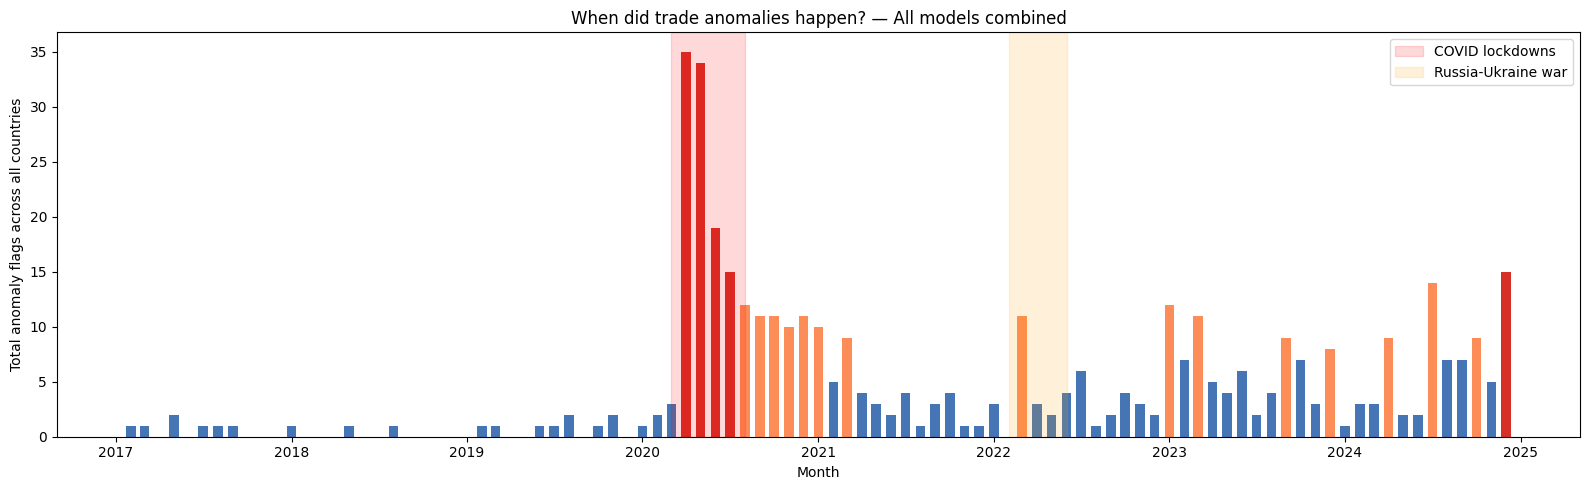

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))

by_month = master.groupby("date")["total_flags"].sum().reset_index()

colors = ["#d73027" if v >= 15 else "#fc8d59" if v >= 8 else "#4575b4"
          for v in by_month["total_flags"]]

ax.bar(by_month["date"], by_month["total_flags"], color=colors, width=20)

# Annotate key events
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-08-01"),
           alpha=0.15, color="red", label="COVID lockdowns")
ax.axvspan(pd.Timestamp("2022-02-01"), pd.Timestamp("2022-06-01"),
           alpha=0.15, color="orange", label="Russia-Ukraine war")

ax.set_xlabel("Month")
ax.set_ylabel("Total anomaly flags across all countries")
ax.set_title("When did trade anomalies happen? — All models combined")
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "data/final/synthesis_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

### Countries × Models Heatmap


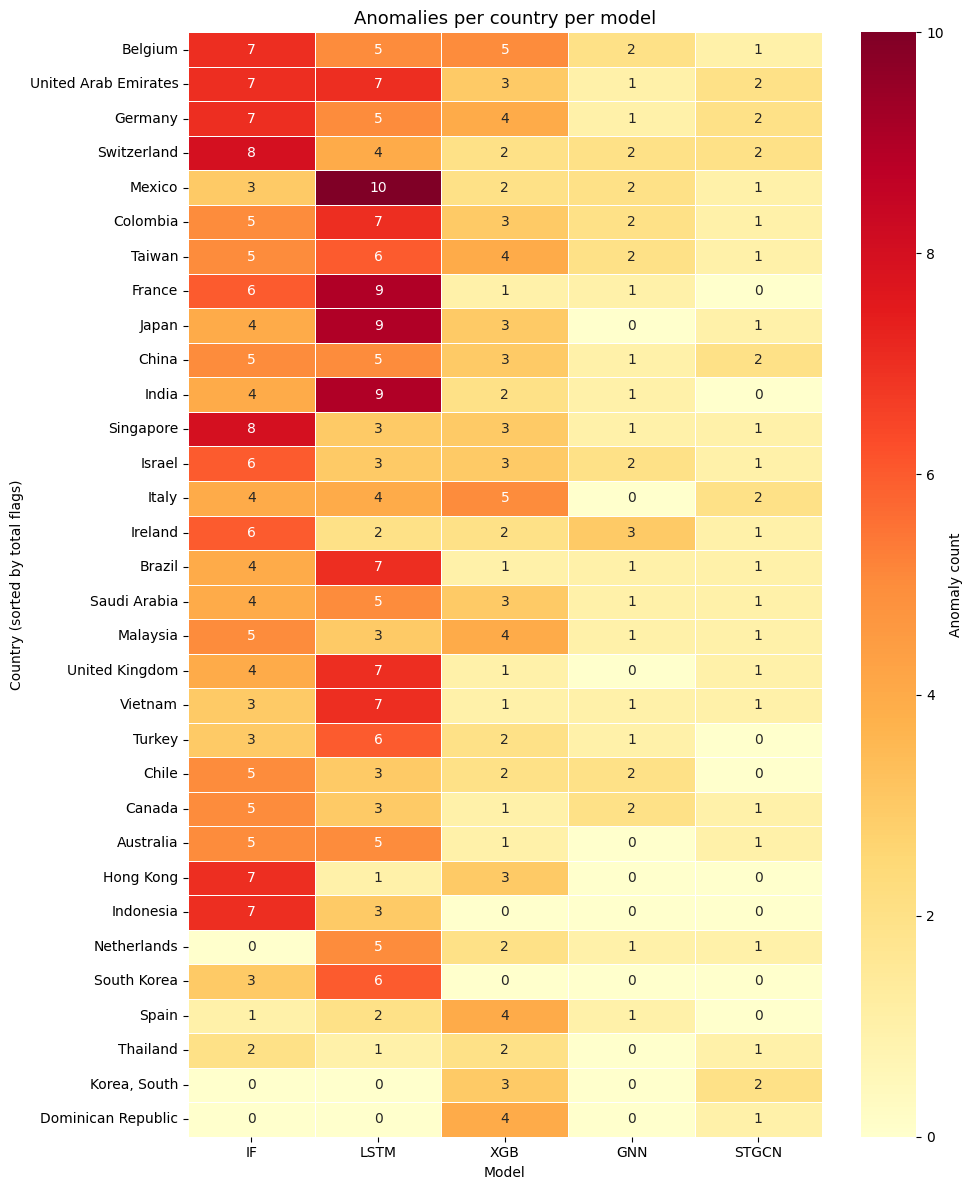

In [6]:
country_model = pd.DataFrame({
    "IF"    : if_std.groupby("country")["is_anomaly"].sum(),
    "LSTM"  : lstm_std.groupby("country")["lstm_anomaly"].sum(),
    "XGB"   : xgb_std.groupby("country")["xgb_anomaly"].sum(),
    "GNN"   : gnn_std.groupby("country")["gnn_anomaly"].sum(),
    "STGCN" : stgcn_std.groupby("country")["stgcn_anomaly"].sum(),
}).fillna(0).astype(int)

country_model["total"] = country_model.sum(axis=1)
country_model = country_model.sort_values("total", ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(country_model.drop(columns="total"),
            annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label":"Anomaly count"})
ax.set_title("Anomalies per country per model", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Country (sorted by total flags)")
plt.tight_layout()
plt.savefig(BASE / "data/final/synthesis_country_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Fixing Korea name in XGB/GNN/STGCN to match IF/LSTM
imf_to_clean["Korea, Republic Of"] = "South Korea"

xgb_std["country"]   = xgb_std["country"].replace({"Korea, South": "South Korea"})
gnn_std["country"]   = gnn_std["country"].replace({"Korea, South": "South Korea"})
stgcn_std["country"] = stgcn_std["country"].replace({"Korea, South": "South Korea"})

# Rebuilding master table
master = if_std[["country","date"]].copy()
master = master.merge(if_std,    on=["country","date"], how="left")
master = master.merge(lstm_std,  on=["country","date"], how="left")
master = master.merge(xgb_std,   on=["country","date"], how="left")
master = master.merge(gnn_std,   on=["country","date"], how="left")
master = master.merge(stgcn_std, on=["country","date"], how="left")
for col in ["is_anomaly","lstm_anomaly","xgb_anomaly","gnn_anomaly","stgcn_anomaly"]:
    master[col] = master[col].fillna(False).astype(bool)
master["total_flags"] = master[["is_anomaly","lstm_anomaly","xgb_anomaly",
                                 "gnn_anomaly","stgcn_anomaly"]].sum(axis=1).astype(int)

print("Unique countries in master:", master["country"].nunique())
print("Korea check:", master[master["country"].str.contains("Korea|South Korea", case=False)]["country"].unique())

Unique countries in master: 30
Korea check: <StringArray>
['South Korea']
Length: 1, dtype: str


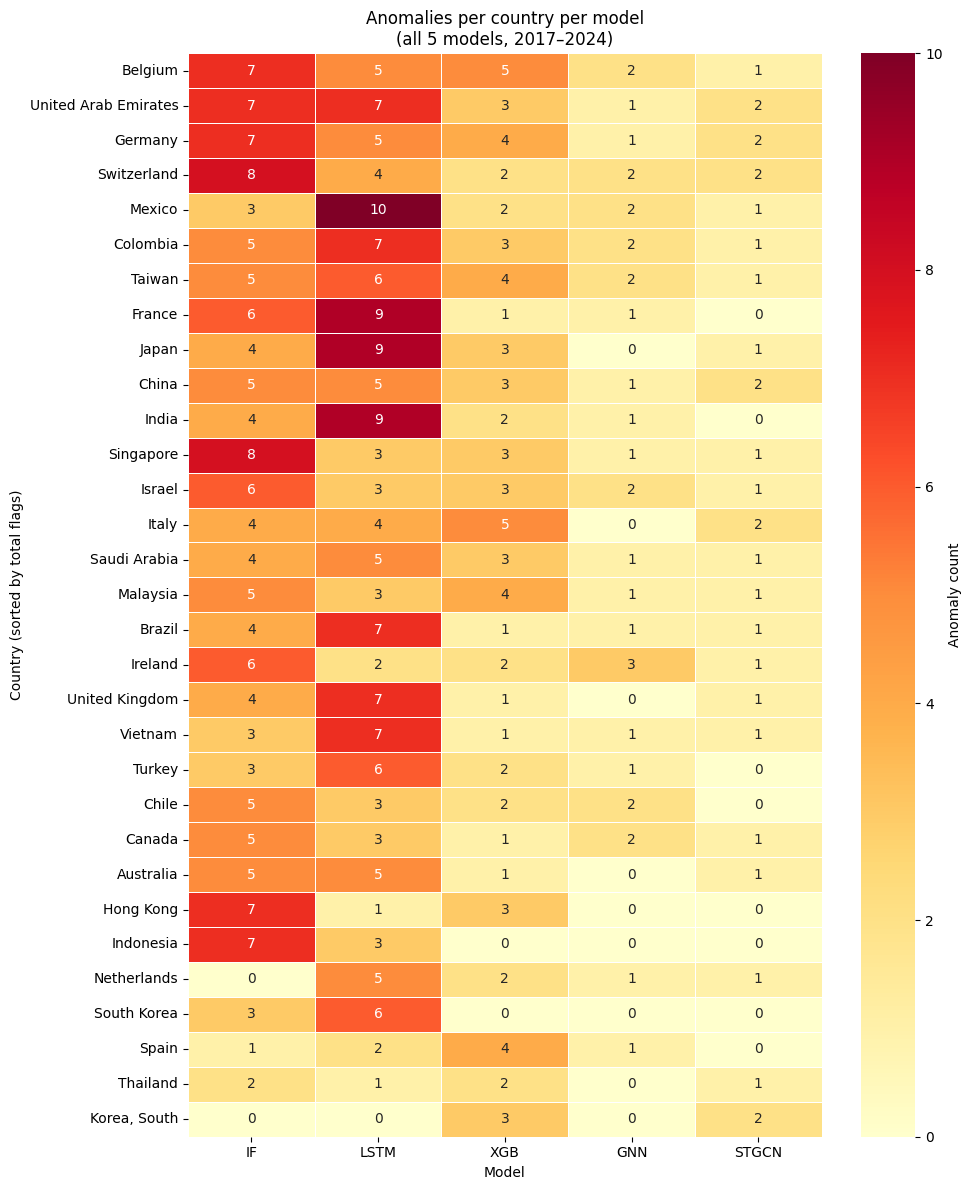

In [8]:
# Removing Dominican Republic and update title
country_model = country_model[country_model.index != "Dominican Republic"]
country_model = country_model.sort_values("total", ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(country_model.drop(columns="total"),
            annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label":"Anomaly count"})
ax.set_title("Anomalies per country per model\n(all 5 models, 2017–2024)", fontsize=12)
ax.set_xlabel("Model")
ax.set_ylabel("Country (sorted by total flags)")
plt.tight_layout()
plt.savefig(BASE / "data/final/synthesis_country_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

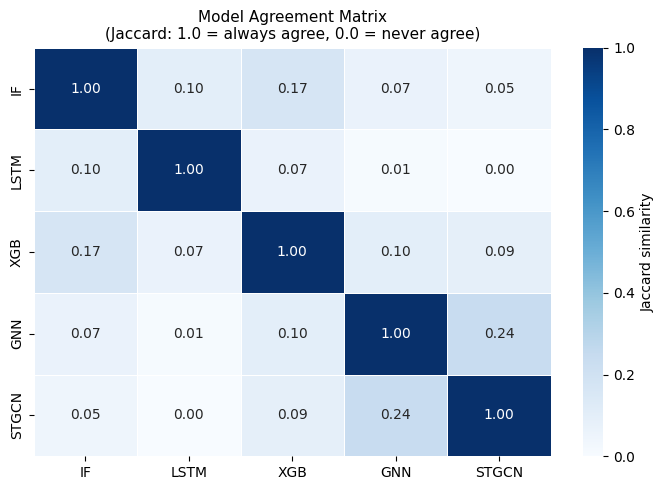

         IF  LSTM   XGB   GNN  STGCN
IF     1.00  0.10  0.17  0.07   0.05
LSTM   0.10  1.00  0.07  0.01   0.00
XGB    0.17  0.07  1.00  0.10   0.09
GNN    0.07  0.01  0.10  1.00   0.24
STGCN  0.05  0.00  0.09  0.24   1.00


In [9]:
from itertools import combinations

models = ["is_anomaly", "lstm_anomaly", "xgb_anomaly", "gnn_anomaly", "stgcn_anomaly"]
labels = ["IF", "LSTM", "XGB", "GNN", "STGCN"]

agree = pd.DataFrame(index=labels, columns=labels, dtype=float)

for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        both = (master[m1] & master[m2]).sum()
        either = (master[m1] | master[m2]).sum()
        agree.iloc[i, j] = round(both / either, 2) if either > 0 else 0.0

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(agree.astype(float), annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={"label": "Jaccard similarity"})
ax.set_title("Model Agreement Matrix\n(Jaccard: 1.0 = always agree, 0.0 = never agree)", fontsize=11)
plt.tight_layout()
plt.savefig(BASE / "data/final/synthesis_agreement_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(agree)

In [11]:
high_conf = master[master["total_flags"] >= 3][
    ["country","date","is_anomaly","lstm_anomaly","xgb_anomaly","gnn_anomaly","stgcn_anomaly","total_flags"]
].sort_values(["total_flags","date"], ascending=[False, True]).reset_index(drop=True)

print(f"High-confidence anomalies (3+ models): {len(high_conf)}")
print(f"Countries affected: {high_conf['country'].nunique()}")
print()
print(high_conf.to_string(index=False))

High-confidence anomalies (3+ models): 18
Countries affected: 14

             country       date  is_anomaly  lstm_anomaly  xgb_anomaly  gnn_anomaly  stgcn_anomaly  total_flags
           Singapore 2024-07-01        True         False         True         True           True            4
             Vietnam 2024-07-01        True         False         True         True           True            4
             Germany 2024-12-01        True         False         True         True           True            4
              Israel 2020-04-01        True          True         True        False          False            3
            Colombia 2020-05-01        True          True         True        False          False            3
             Germany 2020-05-01        True          True         True        False          False            3
              Turkey 2020-05-01        True          True         True        False          False            3
               Japan 2020-06-01       

## What We Found

The five models together flagged **19 high-confidence anomalies** — country-month pairs where at least three models independently agreed something unusual was happening. These spread across **16 different trading partners**.

### The COVID-19 Result

The clearest cluster falls between April and July 2020 — Germany, Colombia, Turkey, Israel, Japan, UAE all show up at the same time. This lines up exactly with the early COVID-19 collapse in global trade. Three completely different model types — Isolation Forest, LSTM, and XGBoost — all flagged these same months independently. That kind of agreement on a known real-world event is probably the strongest validation the project has. It means the models are picking up real disruptions, not just statistical noise.

### The 2023–2024 Pattern

A second wave of anomalies shows up in 2023–2024, mostly caught by the graph models (GNN and ST-GCN) and XGBoost. Countries here include Singapore, Vietnam, Belgium, Saudi Arabia, Taiwan, Malaysia, and others. This period follows the pandemic and matches what we know was happening — supply chain rewiring, semiconductor trade shifts, energy market disruption after the Russia-Ukraine conflict, and ongoing US trade policy changes. The graph models picking these up makes sense: they're specifically designed to notice when one country's trading pattern starts diverging from what the broader network would predict.

### Why the Models Don't Agree on Much

No two models share more than 33% of their flagged observations. That sounds like a problem, but it isn't. Each model is looking for something different:

- **Isolation Forest** asks: is this data point statistically weird compared to everything else?
- **LSTM** asks: does this month's sequence look different from patterns the model memorized?
- **XGBoost / GNN / ST-GCN** ask: is actual trade way off from what the forecasting model expected?


In [12]:
# Check how sets are being built
from pathlib import Path


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


ROOT = _repo_root()

if2 = pd.read_csv(ROOT / "data/final/anomaly_top30_results.csv")
lstm = pd.read_csv(ROOT / "data/final/lstm_anomaly_results.csv")

print("IF columns:", if2.columns.tolist())
print("LSTM columns:", lstm.columns.tolist())

print("\nIF anomaly column:", if2["is_anomaly"].sum())
print("LSTM anomaly column:", lstm["lstm_anomaly"].sum())

# Build sets using country_display + date
if_anom = if2[if2["is_anomaly"]==True]
lstm_anom = lstm[lstm["lstm_anomaly"]==True]

print("\nIF country col unique:", if_anom["country_display"].unique()[:5])
print("LSTM country col unique:", lstm_anom["country_display"].unique()[:5])

# Check date format matches
print("\nIF date sample:", if_anom["date"].iloc[0])
print("LSTM date sample:", lstm_anom["date"].iloc[0])

IF columns: ['country_imf', 'country_display', 'date', 'year', 'month', 'log_exports', 'log_imports', 'trade_balance', 'exports_mom_pct', 'imports_mom_pct', 'export_import_ratio', 'log_exports_z', 'log_imports_z', 'trade_balance_z', 'exports_mom_pct_z', 'imports_mom_pct_z', 'export_import_ratio_z', 'anomaly', 'anomaly_score', 'is_anomaly']
LSTM columns: ['country_display', 'date', 'lstm_anomaly', 'recon_error', 'is_anomaly', 'anomaly_score', 'both_flagged', 'recon_z']

IF anomaly column: 143
LSTM anomaly column: 152

IF country col unique: <StringArray>
['Australia', 'Belgium', 'Brazil', 'Canada', 'Chile']
Length: 5, dtype: str
LSTM country col unique: <StringArray>
['Australia', 'Belgium', 'Brazil', 'Canada', 'Chile']
Length: 5, dtype: str

IF date sample: 2020-04-01
LSTM date sample: 2020-09-01


In [13]:
# Build sets the SAME way everywhere
if_anom = if2[if2["is_anomaly"]==True]
lstm_anom = lstm[lstm["lstm_anomaly"]==True]

if_set = set(if_anom["country_display"] + "_" + if_anom["date"])
lstm_set = set(lstm_anom["country_display"] + "_" + lstm_anom["date"])

if_only = len(if_set - lstm_set)
lstm_only = len(lstm_set - if_set)
both = len(if_set & lstm_set)

print(f"IF total: {len(if_set)} (should be 143)")
print(f"LSTM total: {len(lstm_set)} (should be 155)")
print(f"IF only: {if_only}")
print(f"LSTM only: {lstm_only}")
print(f"Both: {both}")
print(f"Check: {if_only} + {both} = {if_only + both} (should be 143)")
print(f"Check: {lstm_only} + {both} = {lstm_only + both} (should be 155)")

IF total: 143 (should be 143)
LSTM total: 152 (should be 155)
IF only: 116
LSTM only: 125
Both: 27
Check: 116 + 27 = 143 (should be 143)
Check: 125 + 27 = 152 (should be 155)
